# 05 — Évaluation finale et analyse MLflow

Ce notebook :
- Charge tous les runs MLflow et compare les expériences
- Produit les figures finales d'évaluation (ROC, PR, confusion)
- Identifie le meilleur modèle Keras et confirme la traçabilité
- Génère le fichier de traçabilité deployment_traceability.json

In [1]:
import json
from pathlib import Path
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import keras
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as effnet_preprocess
from keras import layers, Model

from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, classification_report, multilabel_confusion_matrix
)

import mlflow

DATA_DIR   = Path('../Projet_Deep_Learning/data/variable_data')
MODELS_DIR = Path('../Projet_Deep_Learning/models')

with open(DATA_DIR / 'config.json') as f:
    cfg = json.load(f)

SEED        = cfg['seed']
IMG_SIZE    = cfg['img_size']
N_CLASSES   = cfg['n_classes']
CLASS_NAMES = cfg['class_names']

np.random.seed(SEED)
tf.random.set_seed(SEED)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)


keras.config.enable_unsafe_deserialization()

print(f'TensorFlow {tf.__version__} | Keras {keras.__version__}')

2026-03-28 15:11:03.792486: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-28 15:11:12.837716: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-03-28 15:11:42.888332: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.20.0 | Keras 3.12.0


## 1. Récupération des runs MLflow

In [2]:
client    = mlflow.tracking.MlflowClient()
exp_names = ['chest_classification_supervised', 'chest_anomaly_detection', 'chest_multimodal']

all_runs = []
for exp_name in exp_names:
    exp = client.get_experiment_by_name(exp_name)
    if exp is None:
        print(f"Expérience '{exp_name}' introuvable.")
        continue
    for run in client.search_runs(experiment_ids=[exp.experiment_id]):
        row = {
            'experiment': exp_name,
            'run_name':   run.data.tags.get('mlflow.runName', run.info.run_id[:8]),
            'run_id':     run.info.run_id,
        }
        row.update(run.data.params)
        row.update({f'metric_{k}': v for k, v in run.data.metrics.items()})
        all_runs.append(row)

runs_df = pd.DataFrame(all_runs)
print(f'Runs récupérés: {len(runs_df)}')

# un petit apercu rapide des runs pour avoir une vue d'ensemble
test_cols = [c for c in runs_df.columns if 'metric_test' in c]
summary   = runs_df[['experiment', 'run_name'] + test_cols].dropna(subset=test_cols, how='all')
print(summary.to_string(index=False))

Runs récupérés: 20
                     experiment        run_name  metric_test_roc_auc  metric_test_pr_auc  metric_test_f1_macro
chest_classification_supervised       ViT_small             0.501812            0.052921              0.063238
chest_classification_supervised EfficientNetV2S             0.768416            0.157789              0.168044
chest_classification_supervised     DenseNet121             0.506597            0.055236              0.071515
chest_classification_supervised     CNN_scratch             0.500035            0.052716              0.062571
chest_classification_supervised EfficientNetV2S             0.765107            0.155844              0.171038
chest_classification_supervised     DenseNet121             0.497888            0.054104              0.074029
chest_classification_supervised     CNN_scratch             0.491732            0.051643              0.055526
chest_classification_supervised     CNN_scratch             0.481554            0.049342     

## 2. Rechargement du meilleur modèle supervisé

In [3]:
X_test_norm = np.load(DATA_DIR / 'X_test_norm.npy')
X_test_rgb  = np.load(DATA_DIR / 'X_test_rgb.npy')
y_test      = np.load(DATA_DIR / 'y_test.npy')

BATCH_SIZE = cfg['batch_size']
AUTOTUNE   = tf.data.AUTOTUNE

test_ds_rgb = (tf.data.Dataset
               .from_tensor_slices((X_test_rgb.astype(np.float32), y_test.astype(np.float32)))
               .batch(BATCH_SIZE).prefetch(AUTOTUNE))

best_model_path = MODELS_DIR / 'best_supervised_model.keras'

def _build_effnet_for_load(img_size, n_classes):
    inp = layers.Input(shape=(img_size, img_size, 3), name='input_rgb')
    x = layers.Lambda(
        lambda img: effnet_preprocess(img * 255.0),
        output_shape=lambda s: s,
        name='imagenet_preprocess'
    )(inp)
    backbone = EfficientNetV2S(include_top=False, weights=None,
                               input_shape=(img_size, img_size, 3), pooling='avg')
    x = backbone(x, training=False)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(n_classes, name='logits')(x)
    return Model(inp, out, name='EfficientNetV2S_TL')

if best_model_path.exists():
    best_model = _build_effnet_for_load(IMG_SIZE, N_CLASSES)
    best_model.load_weights(str(best_model_path))
    print(f'Modèle chargé: {best_model.name}')
else:
    print("Modèle introuvable — exécuter d'abord le notebook 02.")
    best_model = None

I0000 00:00:1774707148.346025   97694 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5578 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Modèle chargé: EfficientNetV2S_TL


## 3. Collecte des prédictions

In [4]:
if best_model is not None:
    all_scores, all_labels = [], []
    for X_batch, y_batch in test_ds_rgb:
        logits = best_model(X_batch, training=False)
        all_scores.append(tf.sigmoid(logits).numpy())
        all_labels.append(y_batch.numpy())

    y_scores = np.vstack(all_scores)
    y_true   = np.vstack(all_labels)
    y_pred   = (y_scores >= 0.5).astype(int)

    valid_cls = [i for i in range(N_CLASSES) if y_true[:, i].sum() > 0]
    print(f'ROC-AUC macro: {roc_auc_score(y_true[:, valid_cls], y_scores[:, valid_cls], average="macro"):.4f}')
    print(f'PR-AUC macro:  {average_precision_score(y_true[:, valid_cls], y_scores[:, valid_cls], average="macro"):.4f}')
    print(f'F1-macro:      {f1_score(y_true, y_pred, average="macro", zero_division=0):.4f}')

2026-03-28 15:12:43.452437: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


2026-03-28 15:19:03.363781: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


ROC-AUC macro: 0.7684
PR-AUC macro:  0.1578
F1-macro:      0.1681


## 4. Courbes ROC par classe

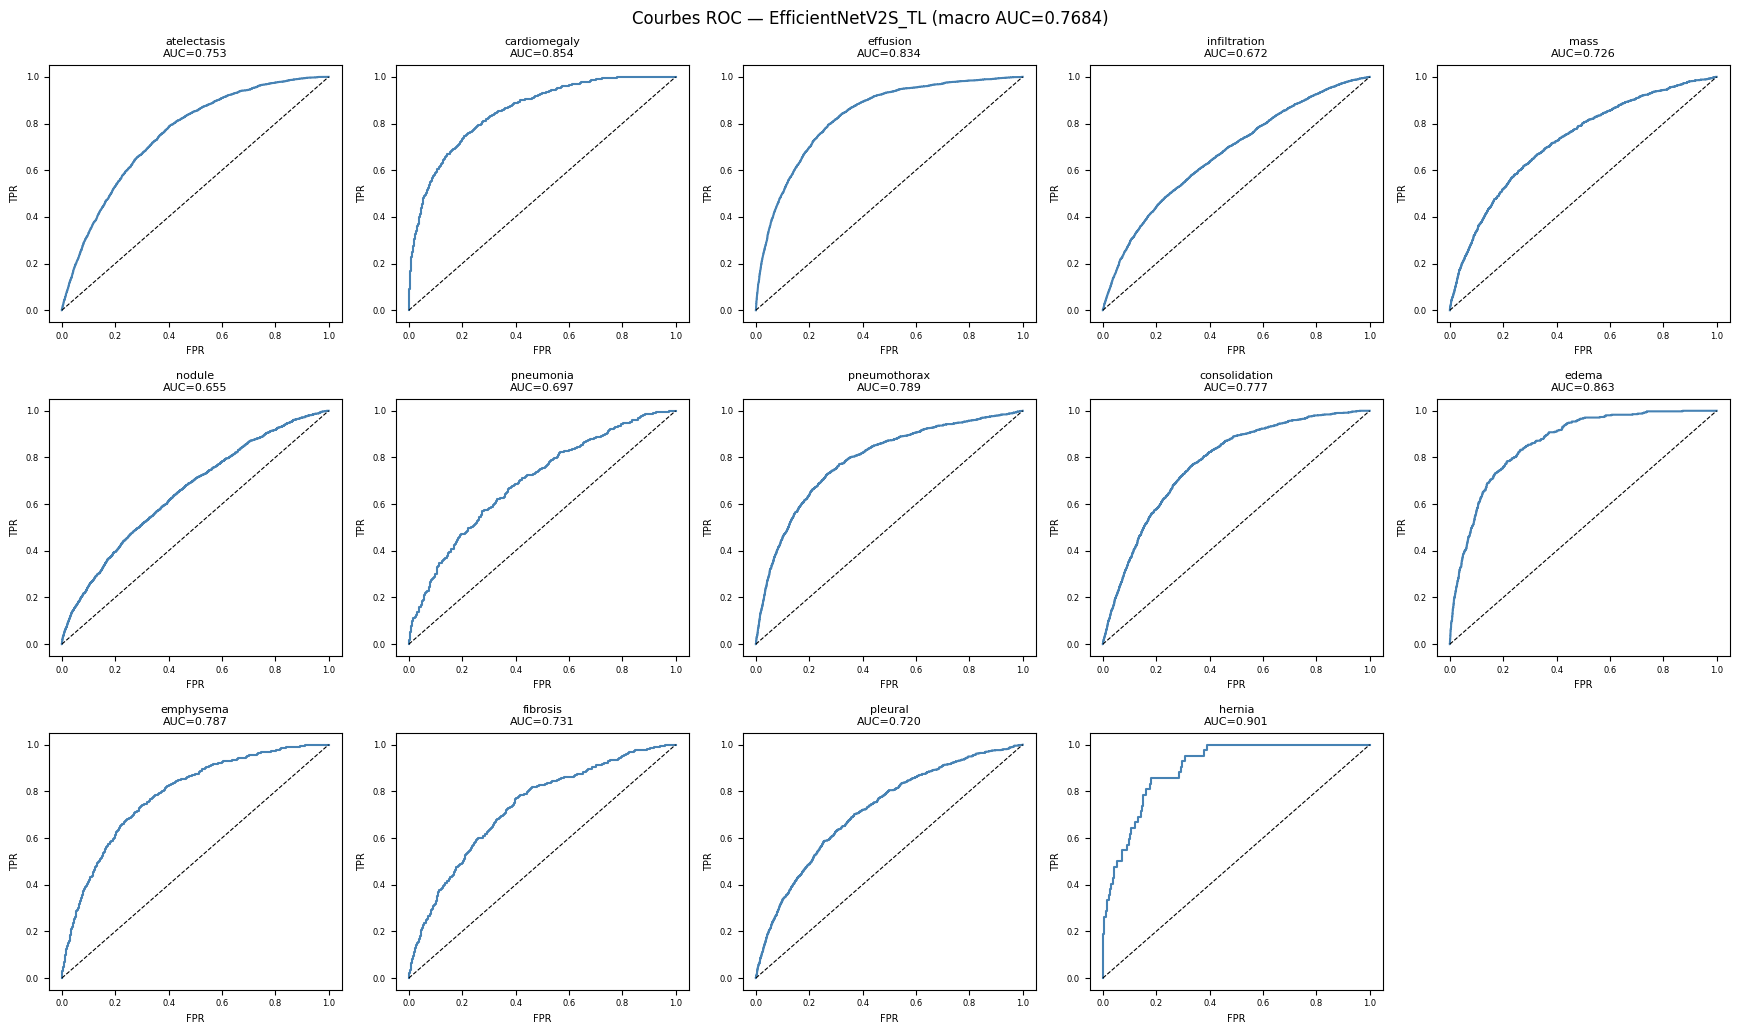

In [5]:
if best_model is not None:
    n_cols = 5
    n_rows = (N_CLASSES + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.5, n_rows * 3.5))
    axes = axes.flatten()

    macro_auc = 0.0
    valid_count = 0

    for i, cls_name in enumerate(CLASS_NAMES):
        if y_true[:, i].sum() == 0:
            axes[i].text(0.5, 0.5, 'Pas de positifs', ha='center', va='center')
            axes[i].set_title(cls_name, fontsize=8)
            continue

        fpr, tpr, _ = roc_curve(y_true[:, i], y_scores[:, i])
        auc_val     = roc_auc_score(y_true[:, i], y_scores[:, i])
        macro_auc  += auc_val
        valid_count += 1

        axes[i].plot(fpr, tpr, color='steelblue', lw=1.5)
        axes[i].plot([0, 1], [0, 1], 'k--', lw=0.8)
        axes[i].set_title(f'{cls_name}\nAUC={auc_val:.3f}', fontsize=8)
        axes[i].set_xlabel('FPR', fontsize=7)
        axes[i].set_ylabel('TPR', fontsize=7)
        axes[i].tick_params(labelsize=6)

    for j in range(N_CLASSES, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'Courbes ROC — {best_model.name} (macro AUC={macro_auc/valid_count:.4f})')
    plt.tight_layout()
    plt.savefig(DATA_DIR / 'roc_curves_per_class.png', dpi=120)
    plt.show()

## 5. Courbes Precision-Recall

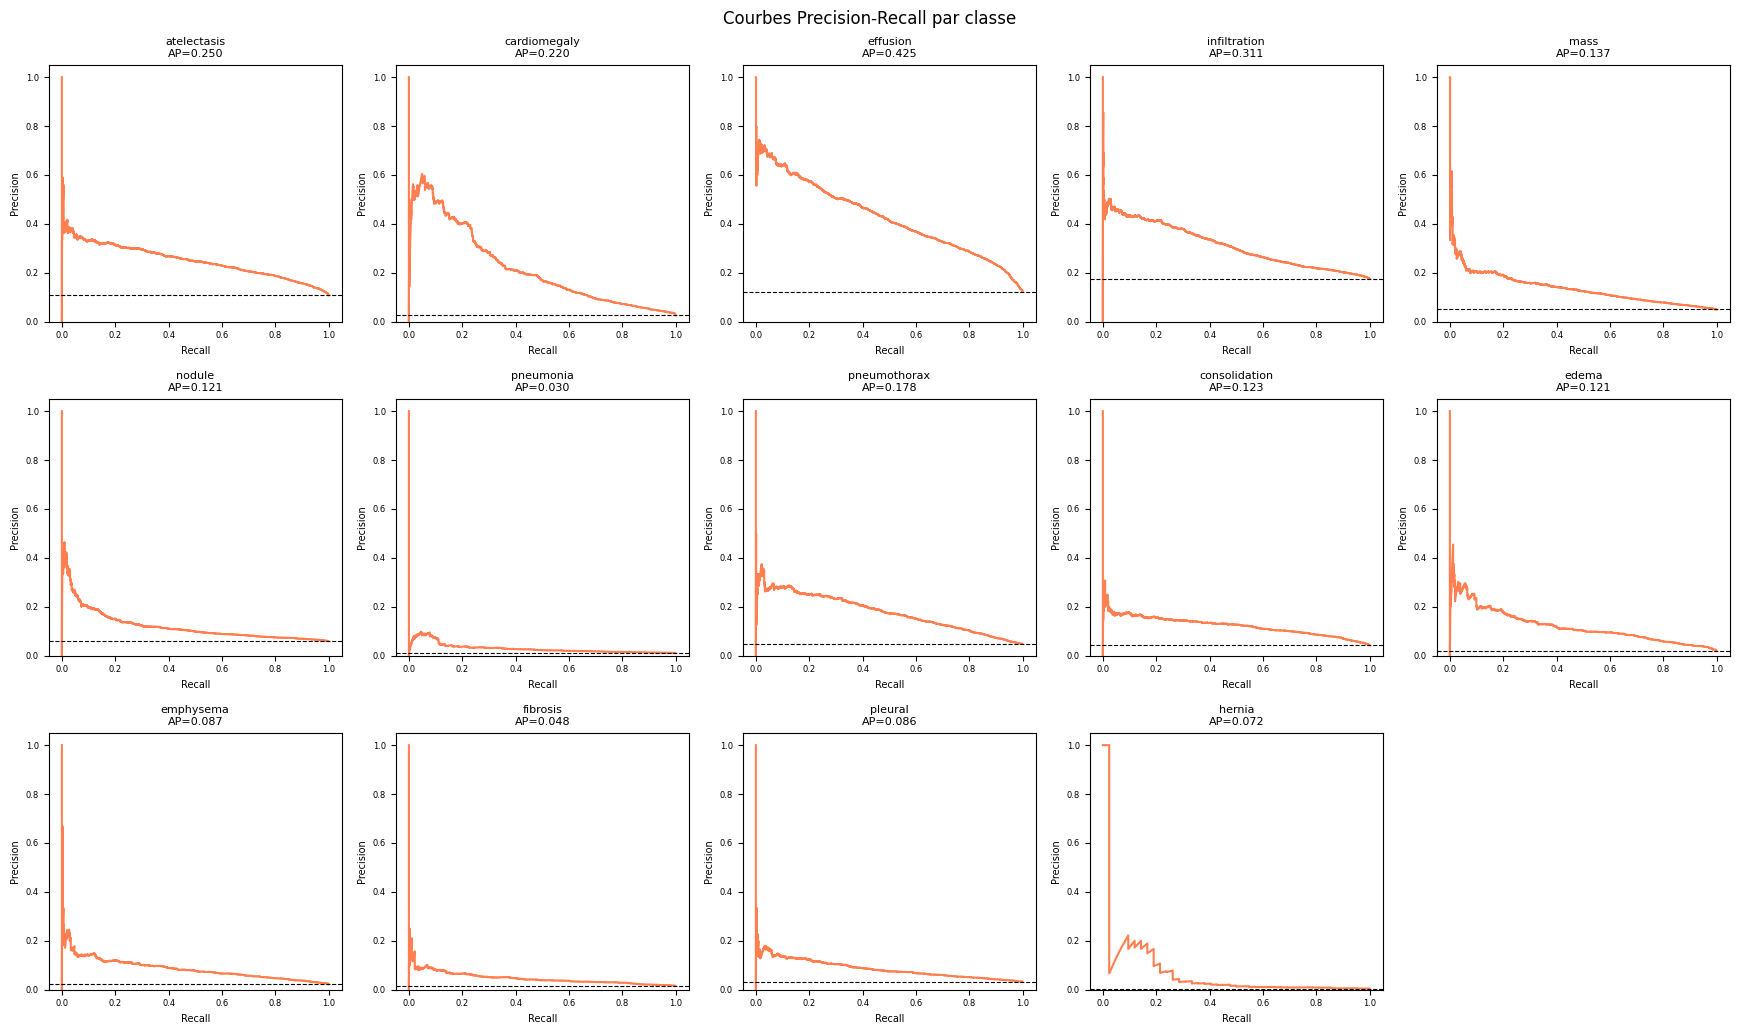

In [6]:
if best_model is not None:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.5, n_rows * 3.5))
    axes = axes.flatten()

    for i, cls_name in enumerate(CLASS_NAMES):
        if y_true[:, i].sum() == 0:
            axes[i].set_title(cls_name, fontsize=8)
            continue

        prec, rec, _ = precision_recall_curve(y_true[:, i], y_scores[:, i])
        ap           = average_precision_score(y_true[:, i], y_scores[:, i])

        axes[i].plot(rec, prec, color='coral', lw=1.5)
        axes[i].axhline(y=y_true[:, i].mean(), color='k', linestyle='--', lw=0.8)
        axes[i].set_title(f'{cls_name}\nAP={ap:.3f}', fontsize=8)
        axes[i].set_xlabel('Recall', fontsize=7)
        axes[i].set_ylabel('Precision', fontsize=7)
        axes[i].set_ylim(0, 1.05)
        axes[i].tick_params(labelsize=6)

    for j in range(N_CLASSES, len(axes)):
        axes[j].axis('off')

    plt.suptitle('Courbes Precision-Recall par classe')
    plt.tight_layout()
    plt.savefig(DATA_DIR / 'pr_curves_per_class.png', dpi=120)
    plt.show()

## 6. Recall et Precision par classe

Classification report:
               precision    recall  f1-score   support

  atelectasis       0.19      0.78      0.31      2420
 cardiomegaly       0.08      0.77      0.14       582
     effusion       0.28      0.81      0.42      2754
 infiltration       0.28      0.54      0.37      3938
         mass       0.10      0.63      0.18      1133
       nodule       0.10      0.53      0.16      1335
    pneumonia       0.02      0.65      0.04       242
 pneumothorax       0.11      0.77      0.19      1089
consolidation       0.09      0.78      0.16       957
        edema       0.07      0.75      0.12       413
    emphysema       0.04      0.83      0.08       509
     fibrosis       0.03      0.74      0.06       362
      pleural       0.06      0.69      0.11       734
       hernia       0.01      0.86      0.01        42

    micro avg       0.11      0.69      0.19     16510
    macro avg       0.10      0.73      0.17     16510
 weighted avg       0.18      0.69      

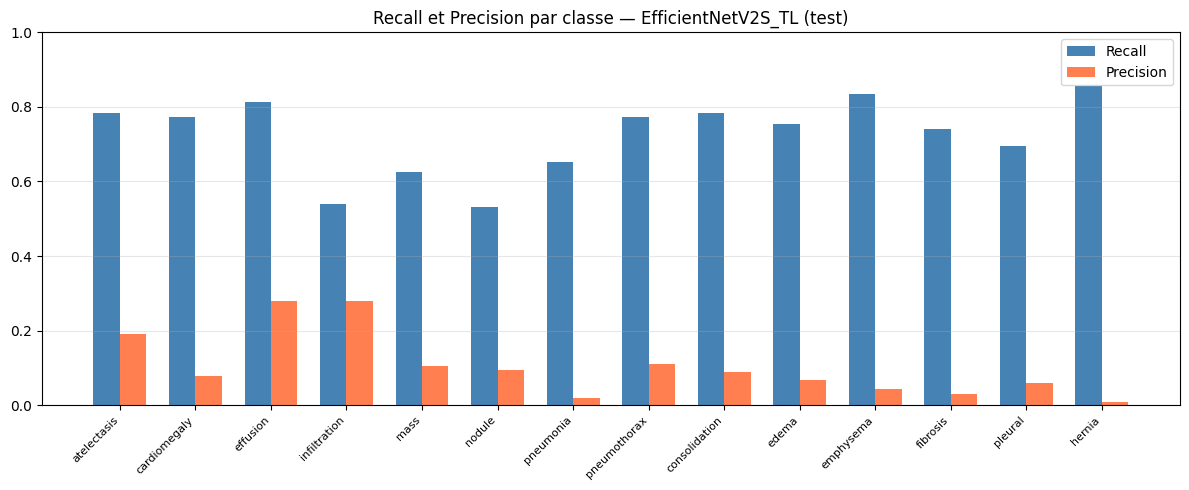

In [7]:
if best_model is not None:
    print('Classification report:')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

    cm_list    = multilabel_confusion_matrix(y_true, y_pred)
    recalls    = []
    precisions = []

    for cm in cm_list:
        tn, fp, fn, tp = cm.ravel()
        recalls.append(tp / (tp + fn + 1e-8))
        precisions.append(tp / (tp + fp + 1e-8))

    x     = np.arange(N_CLASSES)
    width = 0.35
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - width/2, recalls,    width, label='Recall',    color='steelblue')
    ax.bar(x + width/2, precisions, width, label='Precision', color='coral')
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=8)
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.set_title(f'Recall et Precision par classe — {best_model.name} (test)')
    plt.tight_layout()
    plt.savefig(DATA_DIR / 'recall_precision_by_class.png', dpi=120)
    plt.show()

## 7. Traçabilité MLflow ↔ modèle déployé

In [8]:
if not runs_df.empty and 'metric_test_roc_auc' in runs_df.columns:
    sup_runs = runs_df[runs_df['experiment'] == 'chest_classification_supervised'].copy()
    sup_runs = sup_runs.dropna(subset=['metric_test_roc_auc'])

    if not sup_runs.empty:
        best_run = sup_runs.loc[sup_runs['metric_test_roc_auc'].idxmax()]

        print('=== Meilleur run supervisé ===')
        print(f'Run name:     {best_run["run_name"]}')
        print(f'Run ID:       {best_run["run_id"]}')
        print(f'Test AUC:     {best_run["metric_test_roc_auc"]:.4f}')

        traceability = {
            'deployed_model':  str(MODELS_DIR / 'best_supervised_model.keras'),
            'mlflow_run_id':   best_run['run_id'],
            'mlflow_run_name': best_run['run_name'],
            'test_roc_auc':    float(best_run['metric_test_roc_auc']),
            'framework':       'keras/tensorflow'
        }
        with open(MODELS_DIR / 'deployment_traceability.json', 'w') as f:
            json.dump(traceability, f, indent=2)

        print(f'\nFichier de traçabilité: {MODELS_DIR / "deployment_traceability.json"}')

=== Meilleur run supervisé ===
Run name:     EfficientNetV2S
Run ID:       362c6f07989746e5a05e82ef63410c97
Test AUC:     0.7684

Fichier de traçabilité: ../Projet_Deep_Learning/models/deployment_traceability.json


## 8. Log des figures finales dans MLflow

In [9]:
if best_model is not None:
    with mlflow.start_run(run_name='final_evaluation_report'):
        mlflow.log_metrics({
            'final_test_roc_auc': roc_auc_score(y_true[:, valid_cls], y_scores[:, valid_cls], average='macro'),
            'final_test_pr_auc':  average_precision_score(y_true[:, valid_cls], y_scores[:, valid_cls], average='macro'),
            'final_test_f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        })

        for artifact_path in [
            DATA_DIR / 'roc_curves_per_class.png',
            DATA_DIR / 'pr_curves_per_class.png',
            DATA_DIR / 'recall_precision_by_class.png',
            DATA_DIR / 'model_comparison.png',
            DATA_DIR / 'multimodal_comparison.png',
            DATA_DIR / 'anomaly_score_distribution.png',
            MODELS_DIR / 'deployment_traceability.json',
        ]:
            if Path(artifact_path).exists():
                mlflow.log_artifact(str(artifact_path))

        print('Figures et métriques finales loggées dans MLflow.')

Figures et métriques finales loggées dans MLflow.
